In [71]:
import numpy as np
from scipy.spatial import Voronoi,voronoi_plot_2d
import matplotlib.pyplot as plt
import random as rnd

In [89]:
# 1. Generate 20 random 2D points (centers) in the range [0, 10]
np.random.seed(42)  # For reproducible results
points = np.random.rand(20, 2) * 10  # 20 rows, 2 columns, scale to 0-10

In [90]:
points[:4]

array([[3.74540119, 9.50714306],
       [7.31993942, 5.98658484],
       [1.5601864 , 1.5599452 ],
       [0.58083612, 8.66176146]])

In [91]:
# 2. Create Voronoi diagram from these points
vor = Voronoi(points)

**`Voronoi(points)`**  
   The core calculation. It computes:
   - `vor.vertices`: The corner points where boundaries meet
   - `vor.ridge_vertices`: Which vertices connect to form boundaries
   - `vor.regions`: List of points for each polygon region
   - `vor.points`: Your original input points


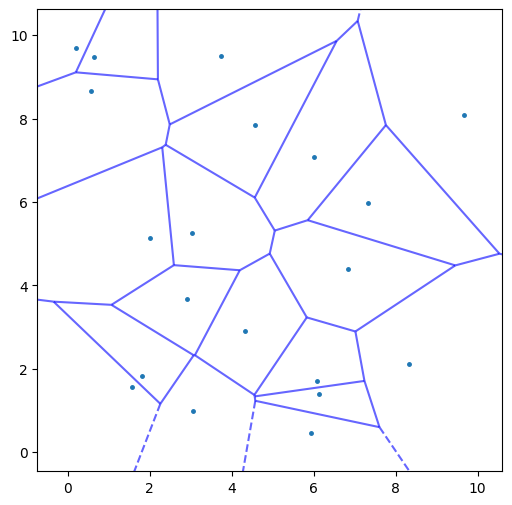

In [92]:
# 3. Plot the Voronoi diagram
fig, ax = plt.subplots(figsize=(6, 6))

# This function draws:
# - Ridge lines (the boundaries between regions)
# - Original points (centers)
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='blue', 
                line_width=1.5, line_alpha=0.6, point_size=5)
plt.show()

In [98]:
polygons = []
for i in range(len(points)):
    region_idx = vor.point_region[i]
    region = vor.regions[region_idx]
    if region and -1 not in region:
        polygon = vor.vertices[region]
        polygon = vor.vertices[region]
        x_min, y_min = polygon.min(axis=0)  # [min_x, min_y]
        x_max, y_max = polygon.max(axis=0)  # [max_x, max_y]
        if(max([x_max,y_max])<10) and (min([x_min,y_min])>0):
            polygons.append(polygon)

```python
if region and -1 not in region:
```
This checks two things:

### 1. `if region` - Ensures the region is not empty
Sometimes `vor.regions` can contain empty lists (`[]`). This check skips those.

### 2. `-1 not in region` - Filters out unbounded regions

**`-1` is a special marker** in scipy's Voronoi implementation that indicates **"infinity"** or an **open/unbounded** edge.

- **If a region contains `-1`** → It extends to infinity (touches the diagram's border)
- **If a region has NO `-1`** → It's a closed polygon (completely bounded by other points)



**Summary:** This condition keeps only the "complete" polygons that are fully surrounded by other points, ignoring edge regions that extend to the diagram's borders.

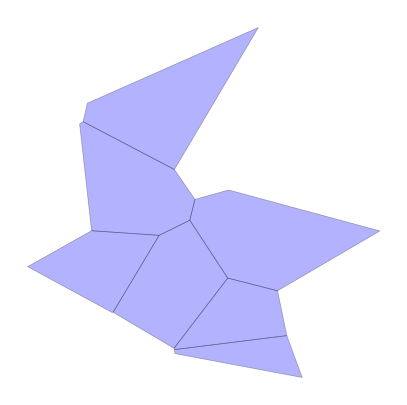

In [99]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

# Plot only the selected polygons (within circle)
for polygon in polygons:
    ax.fill(polygon[:, 0], polygon[:, 1], alpha=0.3, edgecolor='black', facecolor="blue",linewidth=0.5)
plt.axis('off')
plt.show()

In [100]:
polygons[0]

array([[2.39073579, 7.37219023],
       [2.30660369, 7.31153222],
       [2.59097243, 4.48545161],
       [4.19805171, 4.36270882],
       [4.92848203, 4.76213956],
       [5.05145579, 5.31446489],
       [4.56277284, 6.10586632]])

In [101]:
points_string = ' '.join([f"{x},{y}" for x, y in polygons[0]])

In [102]:
points_string

'2.3907357934793754,7.372190234195507 2.306603690992149,7.311532216231154 2.590972426265428,4.485451612523367 4.198051714958867,4.362708824109516 4.928482025298572,4.76213956087782 5.051455791073004,5.314464887298705 4.562772841798361,6.105866317257287'

In [108]:
svg = f'''<polygon points="{points_string}" 
           fill="lightblue" 
           stroke="blue" 
           stroke-width="2" 
           fill-opacity="0.6"/>
'''

In [106]:
svg

'\n  <polygon points="2.3907357934793754,7.372190234195507 2.306603690992149,7.311532216231154 2.590972426265428,4.485451612523367 4.198051714958867,4.362708824109516 4.928482025298572,4.76213956087782 5.051455791073004,5.314464887298705 4.562772841798361,6.105866317257287" \n           fill="lightblue" \n           stroke="blue" \n           stroke-width="2" \n           fill-opacity="0.6"/>\n</svg>'

In [ ]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon


fig, ax = plt.subplots(figsize=(10, 10))

for polygon in polygons:
    # Extract x and y coordinates from the exterior
    x, y = polygon.exterior.xy
    ax.fill(x, y, alpha=0.3, edgecolor='black', facecolor="blue", linewidth=0.5)

plt.axis('off')
plt.show()